<a href="https://colab.research.google.com/github/muffinboy-kor/credit-scoring-model/blob/main/%EC%8B%A0%EC%9A%A9%ED%8F%89%EA%B0%80%EB%AA%A8%EB%8D%B8%EB%A7%81_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("준비 완료!")

pandas: 2.2.2
numpy: 2.0.2
준비 완료!


In [3]:
np.random.seed(42)
N = 15000

n_default = int(N * 0.067)  # 부도 고객 약 6.7%
n_normal  = N - n_default   # 정상 고객

print(f"전체: {N}명")
print(f"부도: {n_default}명")
print(f"정상: {n_normal}명")

전체: 15000명
부도: 1005명
정상: 13995명


In [6]:
def make_customers(n, is_default):
    d = is_default

    return pd.DataFrame({
        # 한도 소진율: 부도 고객은 한도를 꽉 채워 씀
        'RevolvingUtilizationOfUnsecuredLines': np.clip(
            np.random.beta(3 if d else 1.5, 2 if d else 4, n)
            + np.random.normal(0, 0.15, n), 0, 2
        ),
        # 나이
        'age': np.clip(
            np.random.normal(45 if d else 52, 12, n), 18, 90
        ).astype(int),
        # 30~59일 단기 연체 횟수
        'NumberOfTime30_59DaysPastDue': np.random.choice(
            [0,1,2,3,4], n,
            p=[0.55,0.22,0.12,0.07,0.04] if d else [0.93,0.04,0.02,0.007,0.003]
        ),
        # 부채 비율
        'DebtRatio': np.clip(
            np.random.beta(3 if d else 1, 3 if d else 5, n)
            + np.random.normal(0, 0.1, n), 0, 2
        ),
        # 월 소득 (선정산 맥락: 월 매출)
        'MonthlyIncome': np.clip(
            np.random.lognormal(7.9 if d else 8.2, 0.7, n), 500, 80000
        ),
        # 활성 신용거래 수
        'NumberOfOpenCreditLines': np.clip(
            np.random.poisson(7 if d else 9, n), 0, 30
        ).astype(int),
        # 90일 이상 장기 연체 횟수
        'NumberOfTimes90DaysLate': np.random.choice(
            [0,1,2,3], n,
            p=[0.60,0.22,0.12,0.06] if d else [0.988,0.008,0.003,0.001]
        ),
        # 부동산 담보 대출 수
        'NumberRealEstateLoans': np.clip(
            np.random.poisson(0.7 if d else 1.3, n), 0, 8
        ).astype(int),
        # 60~89일 중기 연체 횟수
        'NumberOfTime60_89DaysPastDue': np.random.choice(
            [0,1,2,3], n,
            p=[0.62,0.20,0.12,0.06] if d else [0.975,0.015,0.007,0.003]
        ),
        # 부양 가족 수
        'NumberOfDependents': np.clip(
            np.random.poisson(1.1 if d else 0.8, n), 0, 7
        ).astype(int),

        'SeriousDlqin2yrs': int(d)  # 타겟: 부도 여부
    })

print("함수 정의 완료")

함수 정의 완료


In [7]:
df = pd.concat([
    make_customers(n_default, is_default=True),
    make_customers(n_normal, is_default=False)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['SeriousDlqin2yrs'].value_counts())

(15000, 11)
SeriousDlqin2yrs
0    13995
1     1005
Name: count, dtype: int64


In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
df.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30_59DaysPastDue,DebtRatio,MonthlyIncome,NumberOfOpenCreditLines,NumberOfTimes90DaysLate,NumberRealEstateLoans,NumberOfTime60_89DaysPastDue,NumberOfDependents,SeriousDlqin2yrs
0,0.551200,43,2,0.062376,2675.360374,5,0,1,0,0,0
1,0.065586,64,0,0.191698,6419.018785,10,0,0,0,0,0
2,0.334010,35,0,0.169658,3416.965080,16,0,1,0,2,0
3,0.171191,38,0,0.752193,3544.909466,4,3,0,2,0,1
4,0.614987,42,0,0.410489,11465.244703,8,0,1,0,2,0


In [12]:
df.columns = [
    '한도소진율',
    '나이',
    '단기연체_30_59일',
    '부채비율',
    '월매출',
    '활성신용거래수',
    '장기연체_90일이상',
    '부동산담보대출수',
    '중기연체_60_89일',
    '부양가족수',
    '부도여부'
]

df.head().round(2)

,한도소진율,나이,단기연체_30_59일,부채비율,월매출,활성신용거래수,장기연체_90일이상,부동산담보대출수,중기연체_60_89일,부양가족수,부도여부
0,0.55,43,2,0.06,2675.36,5,0,1,0,0,0
1,0.07,64,0,0.19,6419.02,10,0,0,0,0,0
2,0.33,35,0,0.17,3416.97,16,0,1,0,2,0
3,0.17,38,0,0.75,3544.91,4,3,0,2,0,1
4,0.61,42,0,0.41,11465.24,8,0,1,0,2,0


In [35]:
df.describe().round(2)

,한도소진율,나이,단기연체_30_59일,부채비율,월매출,활성신용거래수,장기연체_90일이상,부동산담보대출수,중기연체_60_89일,부양가족수,부도여부,연체심각도점수,부채x소진율,연체이력존재,월매출_로그
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,0.30,51.01,0.16,0.20,4546.62,8.87,0.06,1.27,0.08,0.81,0.07,0.54,0.07,0.15,8.18
std,0.23,12.12,0.57,0.18,3613.74,3.02,0.31,1.13,0.38,0.90,0.25,1.80,0.10,0.36,0.70
min,0.00,18.00,0.00,0.00,500.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.22
25%,0.12,43.00,0.00,0.05,2196.06,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.69
50%,0.27,51.00,0.00,0.16,3561.19,9.00,0.00,1.00,0.00,1.00,0.00,0.00,0.03,0.00,8.18
75%,0.45,59.00,0.00,0.29,5721.80,11.00,0.00,2.00,0.00,1.00,0.00,0.00,0.08,0.00,8.65
max,1.39,90.00,4.00,1.07,58146.63,24.00,3.00,7.00,3.00,7.00,1.00,20.00,1.02,1.00,10.97


In [16]:
df.groupby('부도여부').mean().round(2)

,한도소진율,나이,단기연체_30_59일,부채비율,월매출,활성신용거래수,장기연체_90일이상,부동산담보대출수,중기연체_60_89일,부양가족수
부도여부,,,,,,,,,,
0,0.28,51.46,0.11,0.18,4621.93,9.00,0.01,1.31,0.04,0.79
1,0.60,44.74,0.83,0.49,3497.85,7.11,0.63,0.67,0.67,1.09


In [18]:
!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("폰트 설치 완료")

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
폰트 설치 완료


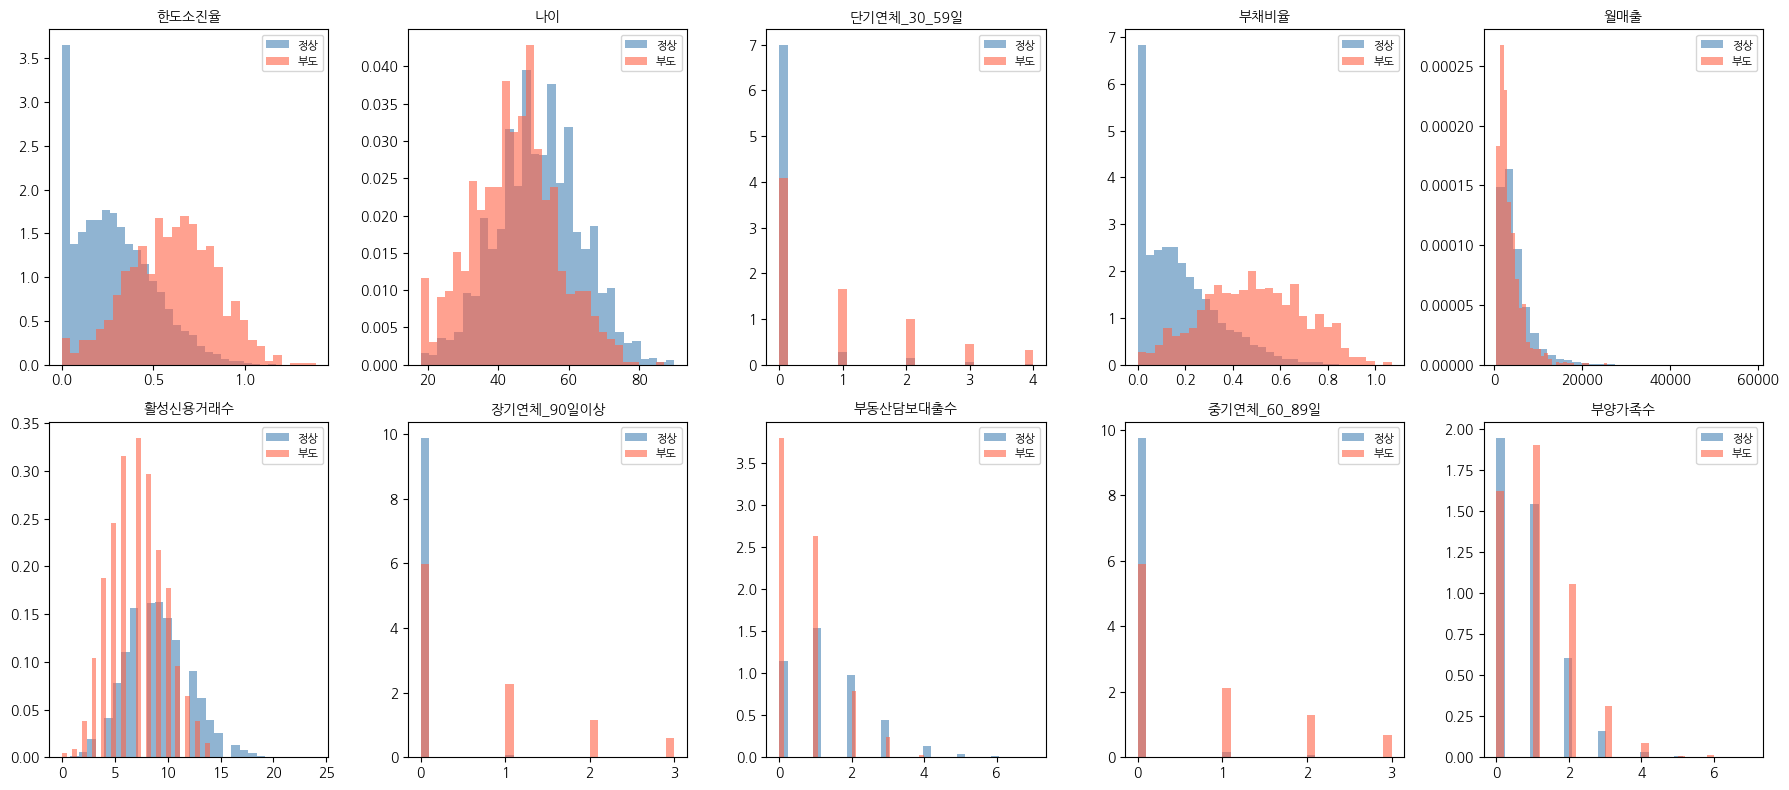

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

columns = [c for c in df.columns if c != '부도여부']

for i, col in enumerate(columns):
    normal  = df[df['부도여부'] == 0][col]
    default = df[df['부도여부'] == 1][col]

    axes[i].hist(normal,  bins=30, alpha=0.6, color='steelblue', label='정상', density=True)
    axes[i].hist(default, bins=30, alpha=0.6, color='tomato',    label='부도', density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
df['연체심각도점수'] = (
    df['단기연체_30_59일'] * 1 +
    df['중기연체_60_89일'] * 2 +
    df['장기연체_90일이상'] * 4
)

# 잘 만들어졌는지 확인
df.groupby('부도여부')['연체심각도점수'].mean().round(2)

,연체심각도점수
부도여부,
0,0.24
1,4.72


In [21]:
df['부채x소진율'] = df['부채비율'] * df['한도소진율']

df.groupby('부도여부')['부채x소진율'].mean().round(2)

,부채x소진율
부도여부,
0,0.05
1,0.29


In [22]:
# 연체 이력 존재 여부 (있다/없다)
df['연체이력존재'] = (df['연체심각도점수'] > 0).astype(int)

# 월매출 로그 변환
df['월매출_로그'] = np.log1p(df['월매출'])

df.groupby('부도여부')[['연체이력존재', '월매출_로그']].mean().round(2)

,연체이력존재,월매출_로그
부도여부,,
0,0.10,8.19
1,0.81,7.92


In [23]:
!pip install lightgbm -q
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [24]:
FEATURES = [
    '한도소진율', '나이', '단기연체_30_59일', '부채비율', '월매출',
    '활성신용거래수', '장기연체_90일이상', '부동산담보대출수',
    '중기연체_60_89일', '부양가족수',
    '연체심각도점수', '부채x소진율', '연체이력존재', '월매출_로그'
]

X = df[FEATURES]
y = df['부도여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

학습 데이터: (12000, 14)
테스트 데이터: (3000, 14)


In [25]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

print("학습 완료!")

학습 완료!


In [26]:
y_pred = model.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, y_pred)

print(f"AUROC: {auroc:.4f}")

AUROC: 0.9769


In [27]:
!pip install shap -q
import shap

print("shap 로드 완료")

shap 로드 완료


In [28]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP 계산 완료")

SHAP 계산 완료


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [30]:
print(type(shap_values))
print(len(shap_values))

<class 'numpy.ndarray'>
3000


In [31]:
sv = shap_values  # [1] 없이 그냥 바로

print(f"shap_values 형태: {sv.shape}")

shap_values 형태: (3000, 14)


/tmp/ipykernel_3654/1063363980.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test, plot_type='bar')


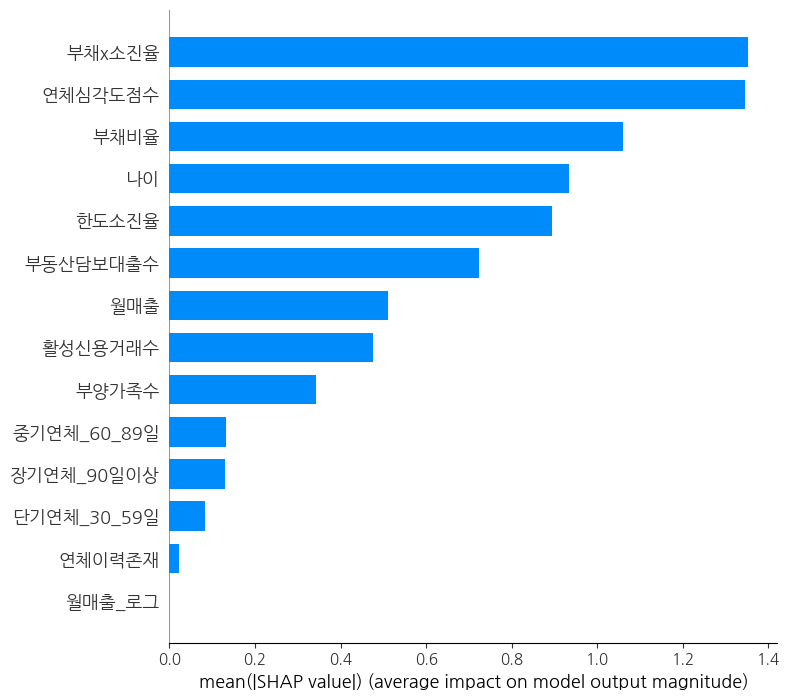

In [32]:
shap.summary_plot(sv, X_test, plot_type='bar')

/tmp/ipykernel_3654/1513492481.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test)


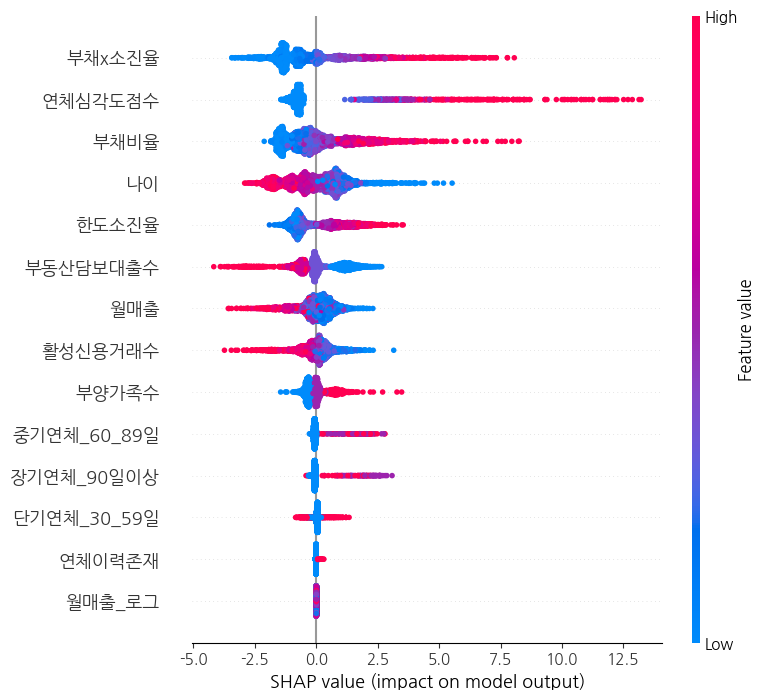

In [33]:
shap.summary_plot(sv, X_test)

In [34]:
df_test = X_test.copy().reset_index(drop=True)
df_test['부도확률'] = y_pred
df_test['실제부도'] = y_test.values
df_test['신용등급'] = pd.qcut(
    df_test['부도확률'].rank(method='first'),
    q=10,
    labels=[f'{i}등급' for i in range(1, 11)]
)

df_test.groupby('신용등급', observed=True)['실제부도'].mean().round(3)

,실제부도
신용등급,
1등급,0.000
2등급,0.000
3등급,0.000
4등급,0.003
5등급,0.000
6등급,0.003
7등급,0.010
8등급,0.020
9등급,0.043
